# ML-Based Student Performance Prediction System

## Objective
Build a machine learning model to predict student academic scores using study habits, attendance, and participation data.

## Dataset Features
- weekly_self_study_hours
- attendance_percentage
- class_participation
- total_score
- grade

## Model Used
Random Forest Regressor

## Conclusion
Study hours had the strongest impact on predicted student performance. Attendance and participation also contributed meaningfully.

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   atten

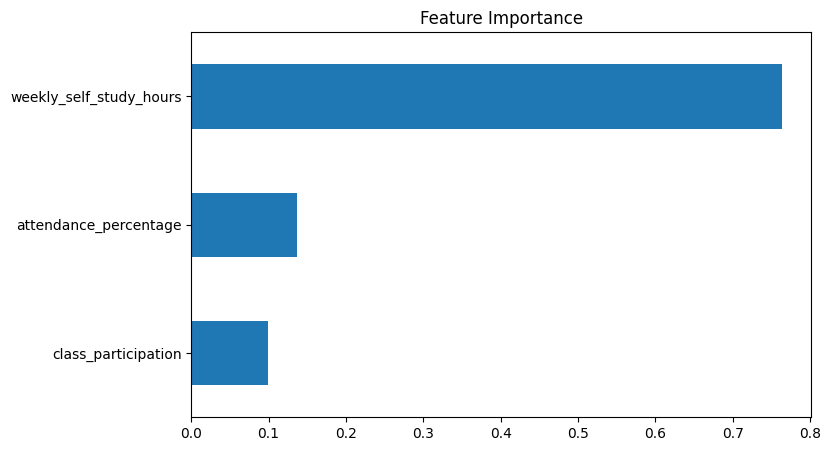

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv('/content/student_performance.csv')

# View data
print(df.head())
print(df.info())

# Features and target
X = df[['weekly_self_study_hours',
        'attendance_percentage',
        'class_participation']]

y = df['total_score']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Metrics
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

# Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()